# Stage 3 – EDA, Step 8: Univariate Distributions (Training Set)

**Project:** Machine Learning-Based U.S. Residential Rental Price Estimation System
**Continues from:** `06_split.ipynb` (Step 7 – the train/test split)

---

## Where we are

The **data-quality phase** (Steps 1–6) is finished, and Step 7 locked away a test set. From now on, the EDA works in a new way:

- **Only the training set is used.** Every table and chart in this notebook comes from `load_train()`. The test set stays closed until the final model is evaluated.
- **The goal changes** from *"is this value wrong?"* to *"what does this feature look like, and how should the model receive it?"*

**Univariate** means *one variable at a time*. This step looks at each feature on its own: its shape, its most common values, its rare values. It deliberately does **not** look at how features relate to rent. That's Step 9. Keeping the two apart stops us from drawing conclusions about rent from charts that were only meant to describe a feature.

## What this step decides

Every model in the project will receive the features through a **preprocessing pipeline** (built later, in the modelling stage). This step collects the evidence for how the pipeline treats each feature:

| Question | Why it matters | Example decision |
|---|---|---|
| Is a numeric feature skewed? | Linear Regression, k-NN and the MLP work best with roughly symmetric inputs on similar scales | log-transform `sqfeet`; standardise everything |
| Is it a count or a measurement? | Counts like bedrooms have natural order | keep `beds` as a number, not a category |
| How many categories does it have? | 400 regions can't be one-hot encoded sensibly for every model | target-encode `region_url` |
| Are some categories very rare? | A model can't learn reliably from a few hundred listings | group rare categories into `"other"` |
| Is a feature almost always the same value? | A feature that barely varies carries little information | keep, but expect little from it |

Step 6 already settled the transform question for `price`, `sqfeet`, `beds` and `baths` on the full clean data. This notebook confirms those findings on the training set and adds the categorical and binary features.

## 8.0 Setup

**What this cell does:** the usual imports and shared helpers, then it loads the **training set** with `load_train()`. It never loads the test set.

**The one threshold used in this notebook comes from `utils.py`:** `RARE_MIN_SHARE = 0.01`. A category with **fewer than 1% of training listings** counts as rare (8.6 explains why 1%). If the import fails with `NameError: RARE_MIN_SHARE`, add these two lines to the end of `src/utils.py`:

```python
# Step 8
RARE_MIN_SHARE = 0.01   # categories with under 1% of training listings are grouped as "other"
```

It also sets up the **feature groups** used throughout: continuous measurements, counts, categories and binary flags. Each group is examined in its own section, because each needs a different kind of chart and a different kind of decision.

In [1]:
# 8.0 Setup

%load_ext autoreload
%autoreload 2

import sys
import warnings
from pathlib import Path
sys.path.append(str(Path.cwd().parent))   # lets Python find the src/ folder

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils import *
setup_display()
warnings.filterwarnings("ignore", category=FutureWarning)

train = load_train()          # the TRAINING set only; the test set stays locked
print(f"Training listings: {len(train):,}")
print(f"Rare-category threshold from utils.py: {RARE_MIN_SHARE:.0%} of training listings "
      f"= {RARE_MIN_SHARE * len(train):,.0f} listings")

CONTINUOUS = ["sqfeet", "lat", "long"]
COUNTS = ["beds", "baths"]
CATEGORICAL = ["region_url", "state", "type", "laundry_options", "parking_options"]
BINARY = BINARY_COLS

show_obs(7)   # Step 7 findings, to confirm the handover

Training listings: 150,404
Rare-category threshold from utils.py: 1% of training listings = 1,504 listings


,step,observation,evidence,decision
0,7-Split,"Final clean dataset: 384,977 -> 381,800 -> 377...",7.1 clean_data() funnel,"All cleaning rules applied once, before the sp..."
1,7-Split,37.1% of clean listings have a close relative ...,7.3 connected components on feature and text keys,Treat each family as one group when splitting ...
2,7-Split,A random stratified split would put 34.72% of ...,7.4 simulated random vs grouped split,Use StratifiedGroupKFold (stratified on log-pr...
3,7-Split,"Training 150,404 (80.0%), test 37,602; KS D = ...","7.5 sizes, 7.6 comparison tables and histogram",The two sets are the same population; the test...
4,7-Split,"Leakage checks: same id: 0, identical features...",7.7 overlap checks,All must be 0 before locking the test set (all...
5,7-Split,Categories seen only in test: {'region_url': 0...,7.8 unseen-category check,Pipeline must handle unknown categories (one-h...
6,7-Split,Training set keeps group_id for grouped cross-...,7.5,Model selection uses GroupKFold on the trainin...


## 8.1 An overview of every feature

**What this cell does:** it builds one table covering all 16 model features. For each feature it shows:

- **kind:** continuous measurement, count, category, or binary flag;
- **unique:** how many different values it has (its *cardinality*);
- **missing_%:** the share of blanks left after cleaning;
- **most_common** and **most_common_%:** the single most frequent value and its share.

**Why we do it:** it's a one-screen summary before the detailed sections, and it immediately answers two questions:

1. **Which features are high-cardinality?** Any category with hundreds of values (like `region_url`) needs special encoding. One-hot encoding would create hundreds of columns.
2. **Which features are near-constant?** If one value covers, say, 95% or more of the listings, the feature can only help for the other 5%. It isn't useless (a rare "yes" can still matter a lot for price), but we shouldn't expect much from it.

**How to read the output:** rows are sorted by kind. The flagged columns at the right mark near-constant features (95% or more one value) and high-cardinality features (over 50 values).

In [2]:
# 8.1 One row per model feature

KIND = {**{c: "continuous" for c in CONTINUOUS}, **{c: "count" for c in COUNTS},
        **{c: "categorical" for c in CATEGORICAL}, **{c: "binary" for c in BINARY}}

rows = []
for col in MODEL_FEATURES:
    s = train[col]
    top = s.value_counts(dropna=False, normalize=True)
    rows.append({
        "feature": col,
        "kind": KIND[col],
        "unique": s.nunique(),
        "missing_%": s.isna().mean() * 100,
        "most_common": top.index[0],
        "most_common_%": top.iloc[0] * 100,
    })
overview = pd.DataFrame(rows).set_index("feature")
overview["near_constant"] = np.where(overview["most_common_%"] >= 95, "yes", "")
overview["high_cardinality"] = np.where((overview["kind"] == "categorical") & (overview["unique"] > 50), "yes", "")
order = ["continuous", "count", "categorical", "binary"]
overview = overview.sort_values("kind", key=lambda k: k.map(order.index))

overview.style.format({"unique": "{:,}", "missing_%": "{:.2f}%", "most_common_%": "{:.1f}%"})

,kind,unique,missing_%,most_common,most_common_%,near_constant,high_cardinality
feature,,,,,,,
sqfeet,continuous,"2,914",0.00%,1000,3.1%,,
lat,continuous,"48,787",0.64%,nan,0.6%,,
long,continuous,"46,120",0.64%,nan,0.6%,,
beds,count,9,0.00%,2,42.8%,,
baths,count,14,0.00%,1.000000,51.2%,,
state,categorical,51,0.00%,ca,10.1%,,yes
type,categorical,10,0.00%,apartment,74.4%,,
region_url,categorical,413,0.00%,https://seattle.craigslist.org,1.1%,,yes
laundry_options,categorical,5,18.08%,w/d in unit,39.2%,,


> 📌 **Findings – what our data showed** (written after reviewing the run outputs)


### 8.1 Findings

- **The model has 16 input features, not 17** as earlier drafts said: 3 continuous (`sqfeet`, `lat`, `long`), 2 counts (`beds`, `baths`), 5 categories (`region_url`, `state`, `type`, `laundry_options`, `parking_options`) and 6 binary flags. The wording in 8.1 and in the 8.8 log was corrected to 16 (the log now counts `MODEL_FEATURES` itself, so it can't drift again).
- **Blanks left after cleaning:** `parking_options` **31.51%**, `laundry_options` **18.08%**, `lat`/`long` **0.64%**. Every other feature is complete. All three are handled in the pipeline (a `"missing"` category for the two options; region-centre fill for coordinates, Step 3).
- **Only one near-constant feature: `electric_vehicle_charge`** (98.1% "no"). It's kept: Step 9 shows the few "yes" listings rent for much more.
- **High-cardinality:** `region_url` (413 values) needs special encoding (8.5). `state` (51) is flagged only because 51 is just above the table's cut-off of 50; one-hot encoding 51 states is no problem with 150,404 rows.
- **Apartments are 74.4%** of training listings, down from 82.6% in the raw data. The most likely reason is Step 4: large apartment complexes posted the most identical copies, so deduplication removed many more apartment rows than other types.
- **Why `lat`'s "most common value" is blank (NaN, 0.6%):** almost every coordinate is unique, so the blank is simply the most frequent single "value". It isn't a problem.

## 8.2 Square footage (`sqfeet`)

**What this cell does:** it summarises `sqfeet` (median, quartiles, skewness) and draws two histograms side by side: the raw values and the log values.

**Two terms used here:**

- **Skewness** measures how lopsided a distribution is. 0 means symmetric. A positive value means a long tail to the right: most homes are modest, and a few are very large. Above about 1 counts as strongly skewed.
- **Kurtosis** measures how heavy the tails are compared with a normal distribution. Values well above 0 mean more extreme values than a bell curve would produce.

**Why it matters for the models:** k-NN measures distances between listings. On the raw scale, the difference between a 3,000 and a 6,000 sq ft house (3,000 sq ft) would count 10 times more than the difference between a 300 sq ft studio and a 600 sq ft one-bed (300 sq ft), even though both are a doubling. The log scale treats both as the same step, which matches how size actually works: doubling a small home matters as much as doubling a large one. Linear Regression and the MLP also behave better with symmetric inputs.

**How to read the output:** compare the skewness of the raw and log versions. Step 6 found 3.27 raw and 0.20 log on the full clean data. The training set should show nearly the same, since it's a random 80% of that data.

,raw,log1p
median,969.00,6.88
Q1 (25%),760.00,6.63
Q3 (75%),"1,200.00",7.09
skewness,2.53,0.14
kurtosis,16.39,1.35


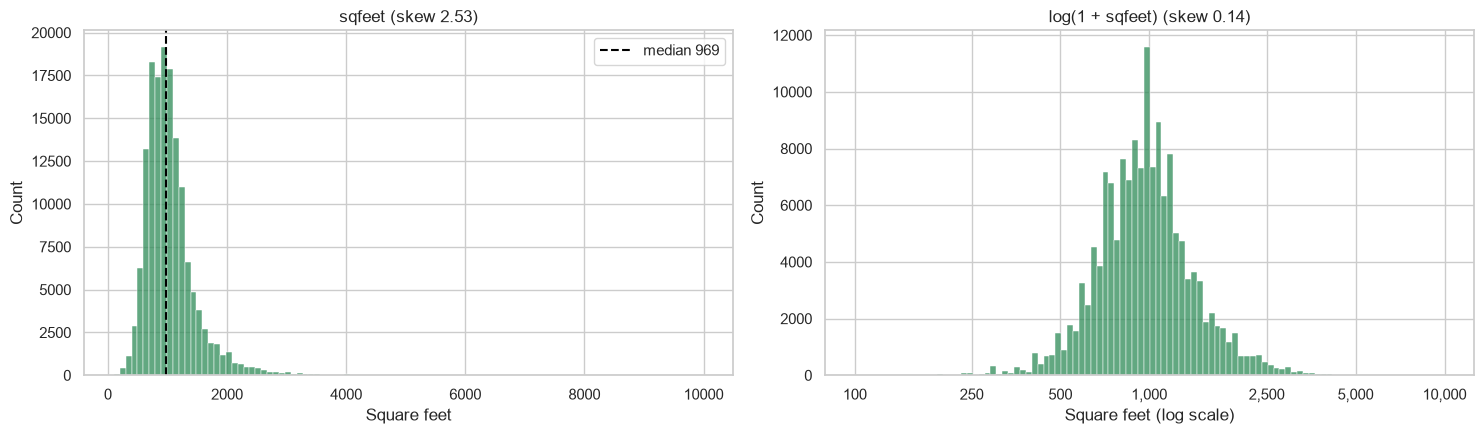

In [3]:
# 8.2 sqfeet: summary and histograms

sq = train["sqfeet"]
log_sq = np.log1p(sq)
summary = pd.DataFrame({
    "raw": [sq.median(), sq.quantile(0.25), sq.quantile(0.75), sq.skew(), sq.kurt()],
    "log1p": [log_sq.median(), log_sq.quantile(0.25), log_sq.quantile(0.75), log_sq.skew(), log_sq.kurt()],
}, index=["median", "Q1 (25%)", "Q3 (75%)", "skewness", "kurtosis"])
display(summary.style.format("{:,.2f}"))

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
sns.histplot(sq, bins=100, ax=axes[0], color="seagreen")
axes[0].axvline(sq.median(), color="black", linestyle="--", label=f"median {sq.median():,.0f}")
axes[0].set(title=f"sqfeet (skew {sq.skew():.2f})", xlabel="Square feet")
axes[0].legend()

sns.histplot(log_sq, bins=100, ax=axes[1], color="seagreen")
ticks = [100, 250, 500, 1000, 2500, 5000, 10000]
axes[1].set_xticks(np.log1p(ticks))
axes[1].set_xticklabels([f"{t:,}" for t in ticks])
axes[1].set(title=f"log(1 + sqfeet) (skew {log_sq.skew():.2f})", xlabel="Square feet (log scale)")
plt.tight_layout()
save_fig("08_sqfeet_distribution")
plt.show()

> 📌 **Findings – what our data showed** (written after reviewing the run outputs)


### 8.2 Findings

- **Typical size:** median **969 sq ft**; the middle half of homes is between **760 and 1,200 sq ft**.
- **Raw sizes are strongly right-skewed** (skewness **2.53**, kurtosis **16.39**): most homes are modest, with a long tail of large houses up to 10,000 sq ft.
- **After `log1p` the distribution is almost symmetric** (skewness **0.14**, kurtosis **1.35**), a near bell shape on the log scale.
- **The spikes in both histograms** are rounded sizes (next cell), not errors.

**Decision (confirmed):** `log1p(sqfeet)` and standardise for Ridge, k-NN and the MLP; raw values for Random Forest and LightGBM (trees only care about the order of values, so a log changes nothing for them).

### 8.2 (cont.) Rounded sizes

**What this cell does:** it checks how often sizes are **round numbers**: multiples of 100 and of 50. It then lists the 10 most common exact sizes.

**Why:** posters often estimate their size ("about 1,000 sq ft") instead of measuring it. If sizes were measured exactly, about 1% of listings would land on a multiple of 100 by chance, and about 2% on a multiple of 50. If the real shares are much higher, many sizes are **estimates**. This is called **heaping**, and you can see it as spikes in the histogram above.

**What it means for the project:** heaping isn't an error to remove. A home described as 1,000 sq ft really is about that size. But it limits how precisely size can predict rent: two listings both entered as 1,000 sq ft might really be 920 and 1,080. It's a **data limitation** worth one sentence in the report, and it's one reason no model will predict rent perfectly from size.

In [4]:
# 8.2 (cont.) How often are sizes round numbers?

round_100 = (sq % 100 == 0).mean() * 100
round_50 = (sq % 50 == 0).mean() * 100
print(f"Multiple of 100 sq ft: {round_100:.1f}% of listings  (about 1% expected if sizes were exact)")
print(f"Multiple of 50 sq ft:  {round_50:.1f}% of listings  (about 2% expected)")

print("\nThe 10 most common exact sizes:")
display(sq.value_counts().head(10).rename("listings").rename_axis("sqfeet").to_frame().T)

Multiple of 100 sq ft: 21.4% of listings  (about 1% expected if sizes were exact)
Multiple of 50 sq ft:  30.5% of listings  (about 2% expected)

The 10 most common exact sizes:


sqfeet,1000,900,1200,1100,800,700,750,600,850,950
listings,4649,3493,3096,2971,2909,2709,2141,2011,2005,1951


> 📌 **Findings – what our data showed** (written after reviewing the run outputs)


### 8.2 (cont.) Findings – heaping

- **21.4%** of sizes are multiples of 100 sq ft (about **1%** expected if sizes were measured) and **30.5%** are multiples of 50 (about **2%** expected). That's about **15 to 21 times** more round numbers than chance.
- **All 10 most common sizes are round numbers**, led by **1,000 sq ft (4,649 listings, 3.1%)**, then 900, 1,200, 1,100 and 800.
- **Meaning:** for a large share of listings, the size is the poster's **estimate**, not a measurement. Size is one of the strongest features, so this is a real **data limitation**: two homes listed as "1,000 sq ft" may really be 900 and 1,150.
- **Effect on models (viva point):** random error in an input makes its estimated effect look **weaker** than it really is (statisticians call this *attenuation*), and it puts a ceiling on how precisely any model can use size. There's no fix in the data, so we report it rather than try to correct it.

## 8.3 Bedrooms and bathrooms

**What this cell does:** it draws a bar chart for each count, with the share of listings printed on every bar, and reports how common half-bathrooms are.

**Why bar charts and not histograms?** Bedrooms and bathrooms take only a handful of exact values (0–8 beds; 0.5–7.5 baths in steps of 0.5). A bar per value shows them exactly. A histogram would group neighbouring values into bins and hide that structure.

**A key encoding decision: number or category?** There are two ways to give `beds` to a model:

- **As a number (0, 1, 2, 3, …):** the model knows that 3 beds is more than 2, and that 2 is more than 1. Linear Regression can learn "each extra bedroom adds about \$X". Trees can split at "beds ≥ 3".
- **As a category ("1 bed", "2 beds", …):** each value gets its own column, and the model *doesn't* know that the values are ordered. It has to learn each one separately, which wastes data, especially for rare values like 7 or 8 bedrooms.

Because bedroom and bathroom counts have a natural order and few rare values, **keeping them as numbers** is the better choice. Step 6 also showed they shouldn't be log-transformed: their tails are short, and the log over-corrects `beds`.

**How to read the output:** look at which values dominate, and how thin the tail is. If 7–8 bedrooms together are well under 1% of listings, the models will have little data to learn their prices, and predictions for very large homes will be less reliable. That's another point for the report.

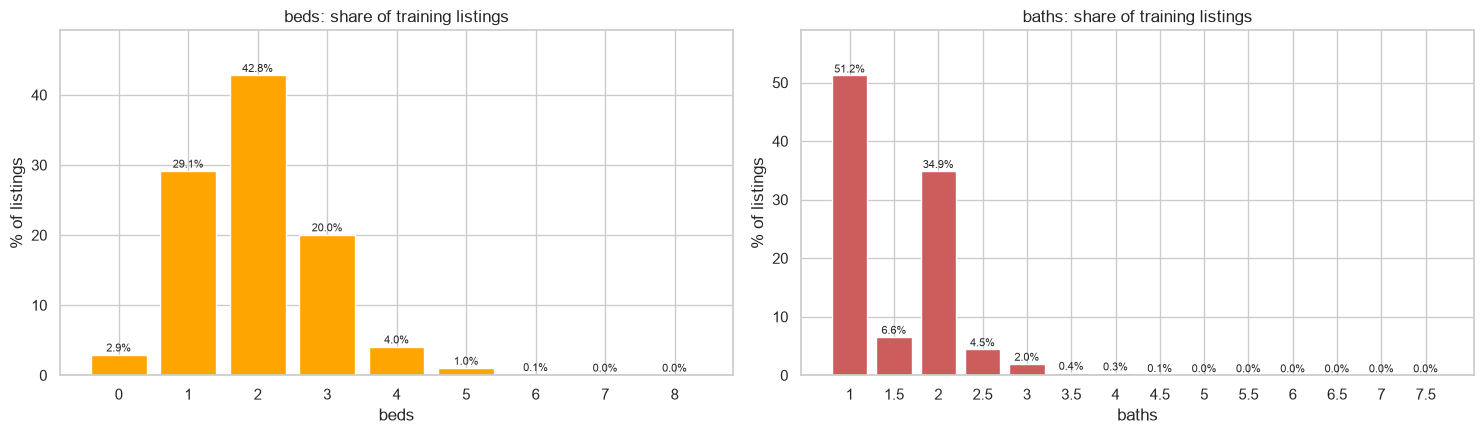

Listings with a half-bathroom (1.5, 2.5, ...): 11.5%
Listings with 6 or more bedrooms:              0.12%
beds: skew 0.56 raw, -0.59 after log1p
baths: skew 0.99 raw, 0.53 after log1p


In [5]:
# 8.3 Bedrooms and bathrooms

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
for ax, col, color in [(axes[0], "beds", "orange"), (axes[1], "baths", "indianred")]:
    share = train[col].value_counts(normalize=True).sort_index() * 100
    labels = [f"{v:g}" for v in share.index]
    ax.bar(labels, share.values, color=color)
    for i, v in enumerate(share.values):
        ax.text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=8)
    ax.set(title=f"{col}: share of training listings", xlabel=col, ylabel="% of listings")
    ax.set_ylim(0, share.max() * 1.15)
plt.tight_layout()
save_fig("08_beds_baths")
plt.show()

half_bath = (train["baths"] % 1 != 0).mean() * 100
big_homes = train["beds"].ge(6).mean() * 100
print(f"Listings with a half-bathroom (1.5, 2.5, ...): {half_bath:.1f}%")
print(f"Listings with 6 or more bedrooms:              {big_homes:.2f}%")
for col in COUNTS:
    print(f"{col}: skew {train[col].skew():.2f} raw, {np.log1p(train[col]).skew():.2f} after log1p")

> 📌 **Findings – what our data showed** (written after reviewing the run outputs)


### 8.3 Findings

- **Bedrooms:** 2 beds is the most common (**42.8%**), then 1 (**29.1%**), 3 (**20.0%**), 4 (**4.0%**), studios (**2.9%**) and 5 (**1.0%**). Only **0.12%** have 6+ bedrooms (about 180 listings).
- **Bathrooms:** 1 bath **51.2%**, 2 baths **34.9%**, 1.5 **6.6%**, 2.5 **4.5%**, 3 **2.0%**; **11.5%** of listings have a half-bathroom, so half-baths are real and common, not typos (as Step 5.3 found).
- **Skewness:** beds **0.56** (mild) and baths **0.99** (moderate). A log makes beds *worse* (**−0.59**, skewed the other way) and only partly helps baths (**0.53**).

**Decision (confirmed):** keep `beds` and `baths` as **numeric counts**, standardised, **no log**. Predictions for very large homes (5+ bedrooms, 3.5+ baths) rest on few examples, so they will be less reliable; Step 11 checks this.

## 8.4 Location: latitude and longitude

**What this cell does:** it reports how many training listings have no coordinates (the original blanks plus the pins blanked in Step 5.5), draws histograms of latitude and longitude, and plots every listing as a dot on a simple map: longitude across, latitude up.

**Why we do it:** coordinates are the most precise location information we have. The map shows **where our data comes from**, and so where the system will be most and least reliable:

- **Dense areas** (the coasts, big metros) have thousands of listings nearby, so predictions there can draw on plenty of examples.
- **Sparse areas** (the Great Plains, the Mountain West) have few listings, so predictions there rely on fewer examples.
- **Alaska and Hawaii** appear as separate small clusters far to the left.

**What the histograms show, and why it matters:** latitude and longitude are **multi-peaked**. Each peak is a region with many listings (for example, the West Coast shows up as a peak in longitude around −122). This matters for Linear Regression, which can only learn straight-line effects: "rent rises by \$X per degree east". Rent doesn't work like that. It's high on both coasts and lower in the middle, which is not a straight line. Tree models handle this naturally by splitting the map into areas. For the linear model, location will come mainly through the **region encoding** (8.5) rather than raw coordinates.

**Note on the map:** the dots are **not** coloured by rent. Colouring by rent would be a relationship with price, which belongs to Step 9. Here, dot density shows only *how many* listings there are in each place.

Training listings without coordinates: 969 (0.64%)  -> filled from their region's centre in the pipeline (Step 3.6)


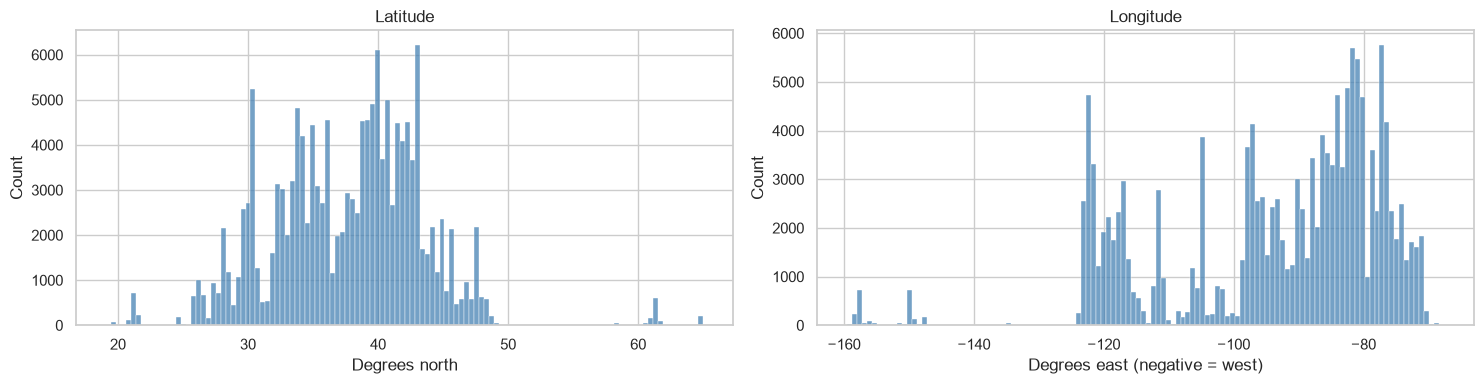

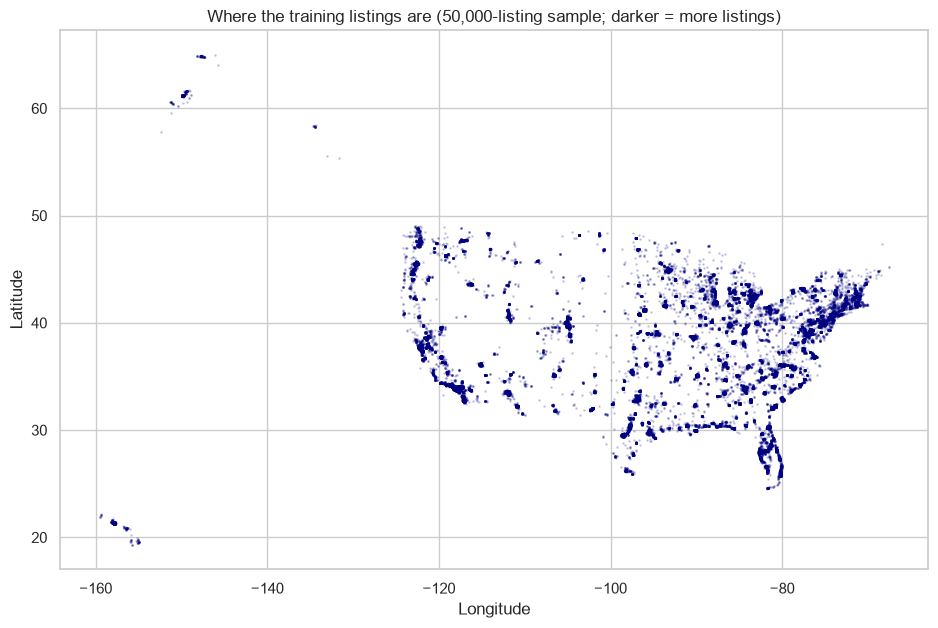

In [6]:
# 8.4 Coordinates: missing pins, histograms and a coverage map

no_pin = train["lat"].isna()
print(f"Training listings without coordinates: {no_pin.sum():,} ({no_pin.mean() * 100:.2f}%)"
      f"  -> filled from their region's centre in the pipeline (Step 3.6)")

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
sns.histplot(train["lat"].dropna(), bins=120, ax=axes[0], color="steelblue")
axes[0].set(title="Latitude", xlabel="Degrees north")
sns.histplot(train["long"].dropna(), bins=120, ax=axes[1], color="steelblue")
axes[1].set(title="Longitude", xlabel="Degrees east (negative = west)")
plt.tight_layout()
save_fig("08_lat_long_histograms")
plt.show()

located = plot_sample(train[~no_pin])
fig, ax = plt.subplots(figsize=(14, 7))
ax.scatter(located["long"], located["lat"], s=1, alpha=0.15, color="navy", rasterized=True)
ax.set(xlabel="Longitude", ylabel="Latitude",
       title=f"Where the training listings are ({len(located):,}-listing sample; darker = more listings)")
ax.set_aspect(1.25)
save_fig("08_listing_map")
plt.show()

> 📌 **Findings – what our data showed** (written after reviewing the run outputs)


### 8.4 Findings

- **969 training listings (0.64%) have no coordinates.** They are filled from their region's centre inside the pipeline (training data only).
- **The histograms are multi-peaked:** latitude and longitude cluster around the big metro areas rather than spreading evenly, which is expected for housing data.
- **Coverage map:** dense along the **West Coast**, the **Northeast corridor** (Boston to Washington), **Florida**, the **Great Lakes** and **Texas**; sparse across the **Mountain West** and **Great Plains**. **Alaska** (Anchorage, Fairbanks area) and **Hawaii** appear as separate clusters, and the Step 5.5–5.6 fixes worked: no pins in the ocean or outside the U.S.
- **Meaning for the system:** predictions will be most reliable where data is dense and least reliable in sparse areas. Coordinates let tree models learn local price zones; Step 9.8 confirms that longitude carries a lot of rent information (η² 22.4%).

## 8.5 Region and state: how many listings per category?

**What this cell does:** for `region_url` (about 400 Craigslist sites) and `state` (51 including D.C.), it reports how many different values there are, and how the number of listings per value is spread: the smallest, the median, the largest, and how many regions have fewer than 30 or 100 listings. It then draws a bar chart of the 15 states with the most listings.

**Why this decides how location is encoded:** with about 400 regions, the usual approach for categories, **one-hot encoding** (one 0/1 column per region), would create about 400 extra columns. That's workable for Linear Regression and the tree models, but poor for **k-NN**, where 400 sparse columns swamp the distance calculation, and wasteful for the MLP.

The alternative is **target encoding**: each region is replaced by *one number*, the average (log) rent of that region's training listings. Two safeguards make it work:

1. **Smoothing.** A region with only 12 listings has an unreliable average; one expensive listing could distort it. Smoothing blends each region's average with the overall average, weighted by how many listings the region has:

   $$\text{encoded value} = \frac{n \cdot \text{region average} + m \cdot \text{overall average}}{n + m}$$

   A region with many listings (large *n*) keeps close to its own average. A small region is pulled towards the overall average. This is why the counts in this cell matter: they show how many regions will be noticeably smoothed.
2. **Cross-fitting.** If a listing's own rent were included in its region's average, the model would see a trace of the answer it's supposed to predict. That's leakage *inside* the training set. scikit-learn's `TargetEncoder` avoids this automatically: it computes each listing's encoding from the *other* folds of the training data.

**State:** after Step 5.7, every region belongs to exactly one state, so `state` is a coarser grouping of `region_url`. Its main value is **pooling**: a small region borrows strength from its whole state. With 51 values, one-hot encoding is fine. Whether it adds anything beyond `region_url` is a redundancy question for Step 10.

**How to read the output:** a large number of regions under 30 listings would mean smoothing does a lot of work. The state chart shows how unevenly the data covers the country.

,region_url,state
categories,413,51
fewest listings,4,125
median listings,200,"2,227"
most listings,"1,698","15,191"
categories with < 30 listings,29,0
categories with < 100 listings,131,0


Largest region: https://seattle.craigslist.org (1,698 listings)
Smallest region: https://bigbend.craigslist.org (4 listings)


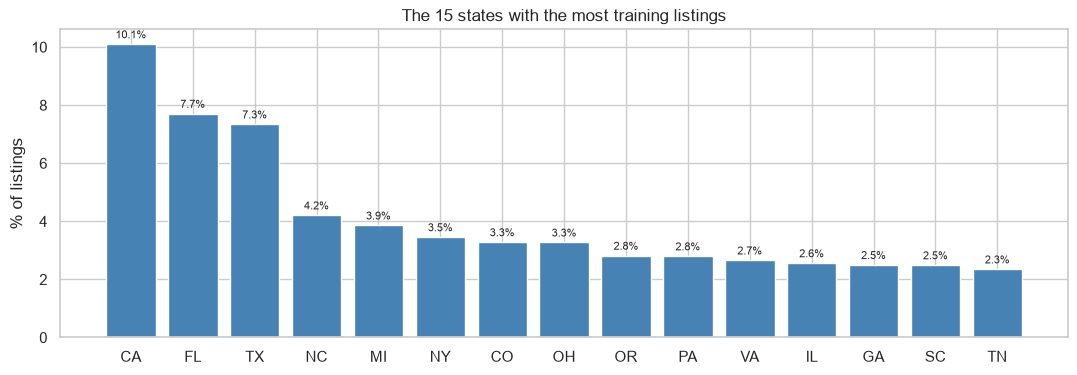

The top 15 states hold 61.4% of all training listings


In [7]:
# 8.5 Listings per region and per state

per_region = train["region_url"].value_counts()
per_state = train["state"].value_counts()

spread = pd.DataFrame({
    "region_url": [len(per_region), per_region.min(), per_region.median(), per_region.max(),
                   (per_region < 30).sum(), (per_region < 100).sum()],
    "state": [len(per_state), per_state.min(), per_state.median(), per_state.max(),
              (per_state < 30).sum(), (per_state < 100).sum()],
}, index=["categories", "fewest listings", "median listings", "most listings",
          "categories with < 30 listings", "categories with < 100 listings"])
display(spread.style.format("{:,.0f}"))

print(f"Largest region: {per_region.index[0]} ({per_region.iloc[0]:,} listings)")
print(f"Smallest region: {per_region.index[-1]} ({per_region.iloc[-1]:,} listings)")

top15 = per_state.head(15)
fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(top15.index.str.upper(), top15.values / len(train) * 100, color="steelblue")
for i, v in enumerate(top15.values / len(train) * 100):
    ax.text(i, v + 0.2, f"{v:.1f}%", ha="center", fontsize=8)
ax.set(title="The 15 states with the most training listings", ylabel="% of listings")
save_fig("08_top15_states")
plt.show()
print(f"The top 15 states hold {top15.sum() / len(train) * 100:.1f}% of all training listings")

> 📌 **Findings – what our data showed** (written after reviewing the run outputs)


### 8.5 Findings

- **413 regions**, with a **median of 200** training listings each. The largest is **Seattle (1,698)**, the smallest **Big Bend, TX (4)**.
- **29 regions have fewer than 30 listings** and **131 (32%) have fewer than 100.** For these, a region's own average rent is unreliable on its own, which is why region needs a **smoothed** target encoding rather than a plain average.
- **51 states** (including D.C.): every state has at least **125** listings (median **2,227**; largest **California, 15,191 = 10.1%**).
- **The top 15 states hold 61.4%** of all training listings, so the data leans towards the populous states: a mild geographic imbalance that Step 11 follows up.

**Decision (confirmed):** `region_url` → **smoothed, cross-fitted target encoding** (`TargetEncoder`); `state` → **one-hot**. (Step 10.5 checks whether small regions should be smoothed towards their state rather than the national average.)

## 8.6 Property type, laundry and parking: rare categories

**What this cell does:** for `type`, `laundry_options` and `parking_options`, it draws a bar chart of every category's share, with blanks shown as `missing` (the category decided in Step 3). Categories below the rare threshold (`RARE_MIN_SHARE`, 1%) are coloured red, and the cell lists them.

**Why rare categories need care:** a model learns a category's effect from the listings that have it. With 150,000 training listings, 1% is about 1,500 listings, which is enough to learn a reasonably stable average. A category with 200 listings gives a much noisier estimate, and during cross-validation some folds might contain only a few dozen of them. Rare categories also cause the "unseen category" problem from Step 7.8: a value that appears in the test set but not in training.

**The standard fix: group rare categories into `"other"`.** In the pipeline this is one setting: `OneHotEncoder(min_frequency=...)` automatically merges every category below the threshold into a single "infrequent" column, learned from the training data. For `type`, that would combine, for example, `cottage/cabin`, `flat`, `loft` and `in-law` into one group.

**Why 1%?** It's a common, simple rule of thumb that works well at this data size. It keeps every category large enough to estimate while merging only the genuinely thin ones. The exact value matters much less than applying it consistently. That's why it lives in `utils.py`, where the pipeline will read the same number.

**The cost to consider:** grouping throws away the difference between the grouped categories. If one of them has a very different typical rent (for example, `valet parking` may be far more expensive than other parking types), grouping hides that. That trade-off can only be judged by looking at rents, so it's revisited in **Step 9**, where we check whether any rare category stands out.

**How to read the output:** the red bars are the categories the pipeline will group. Check how much of the data they cover in total: if it's only a couple of percent, grouping costs very little.

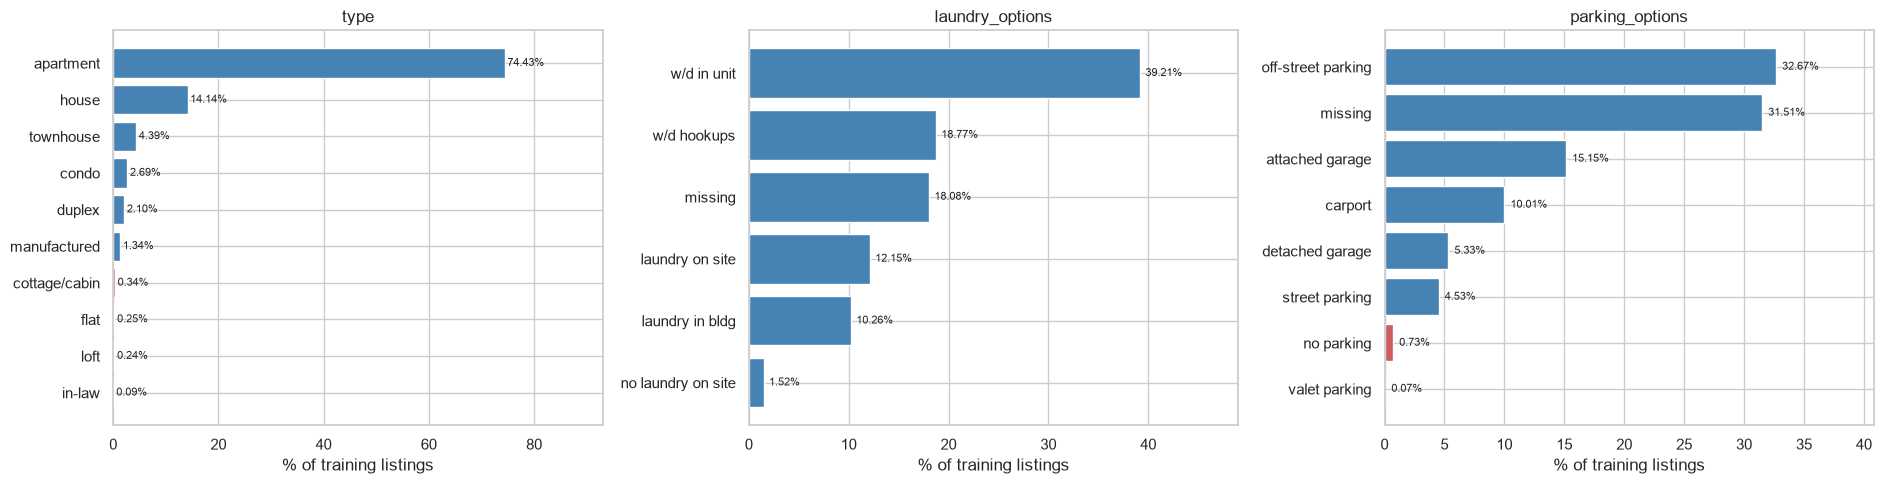

type: rare (< 1%) -> cottage/cabin (0.34%), flat (0.25%), loft (0.24%), in-law (0.09%); together 0.92% of listings
laundry_options: rare (< 1%) -> none; together 0.00% of listings
parking_options: rare (< 1%) -> no parking (0.73%), valet parking (0.07%); together 0.80% of listings


In [8]:
# 8.6 Category shares, with rare categories highlighted

small_cats = ["type", "laundry_options", "parking_options"]
rare = {}

fig, axes = plt.subplots(1, 3, figsize=(19, 5))
for ax, col in zip(axes, small_cats):
    share = train[col].fillna("missing").value_counts(normalize=True) * 100
    is_rare = share < RARE_MIN_SHARE * 100
    rare[col] = share[is_rare]
    ax.barh(share.index[::-1], share.values[::-1],
            color=["indianred" if r else "steelblue" for r in is_rare[::-1]])
    for i, v in enumerate(share.values[::-1]):
        ax.text(v + 0.5, i, f"{v:.2f}%", va="center", fontsize=8)
    ax.set_xlim(0, share.max() * 1.25)
    ax.set(title=col, xlabel="% of training listings")
plt.tight_layout()
save_fig("08_categories_rare_highlighted")
plt.show()

for col, r in rare.items():
    listed = ", ".join(f"{k} ({v:.2f}%)" for k, v in r.items()) if len(r) else "none"
    print(f"{col}: rare (< {RARE_MIN_SHARE:.0%}) -> {listed}; together {r.sum():.2f}% of listings")

> 📌 **Findings – what our data showed** (written after reviewing the run outputs)


### 8.6 Findings

- **`type` (10 categories):** apartment **74.43%**, house **14.14%**, townhouse **4.39%**, condo **2.69%**, duplex **2.10%**, manufactured **1.34%**. **Rare (< 1%):** cottage/cabin 0.34%, flat 0.25%, loft 0.24%, in-law 0.09% (together **0.92%**).
- **`laundry_options`:** w/d in unit **39.21%**, w/d hookups **18.77%**, missing **18.08%**, laundry on site **12.15%**, laundry in bldg **10.26%**, no laundry on site **1.52%**. **No rare category**, although "no laundry on site" is close to the line.
- **`parking_options`:** off-street **32.67%**, missing **31.51%**, attached garage **15.15%**, carport **10.01%**, detached garage **5.33%**, street **4.53%**. **Rare:** no parking **0.73%** and valet parking **0.07%**.
- **The warning sign:** the two rare parking categories are **opposites** ("no parking" vs "valet"), so merging them into one "other" group could hide a real rent difference.

**Result of the follow-up (Step 9.4, notebook 08):** the rare categories are **not** similar in rent (spread 32% for `type`, 65% for `parking_options`), so they are **not** merged blindly. The decision is a minimum *count* instead of a minimum share: every category with **50+ training listings keeps its own column** (`RARE_MIN_COUNT = 50` in `utils.py`). At present that keeps every category.

## 8.7 The six binary flags

**What this cell does:** for each yes/no flag, it shows the share of **yes** (1) as a bar, and marks flags that are **rare** (under 5% yes) or **dominant** (over 95% yes).

**Why:** a binary flag can only help the model distinguish listings if both values are reasonably common. Two cases need attention:

- **A rare "yes"** (like EV charging, which was about 1% in Step 1): the flag describes only a small group. It may still matter for those listings (EV chargers tend to be in newer, pricier buildings), but it can't explain much of the overall variation in rent.
- **A suspiciously common "yes"** (like `smoking_allowed`, which was 73% in Step 1): U.S. rentals mostly *ban* smoking, so such a high share suggests Craigslist may **default** the box to "allowed" when the poster doesn't choose. If so, the flag partly records whether the poster *touched the box*, not the real smoking policy. That's recorded as a **data-reliability limitation** (Step 1 already raised it), and Step 9 will show whether the flag relates to rent at all.

**How binary flags are encoded:** they're already 0/1, so no encoding is needed. For Linear Regression, k-NN and the MLP they're standardised along with the other numeric inputs, so that all features are on a similar scale. Trees use them as they are.

**How to read the output:** compare each bar with the 5% and 95% lines, and compare the shares with Step 1. Cleaning removed about half the rows (mostly duplicates), so if any share changed a lot, duplicates had been distorting it.

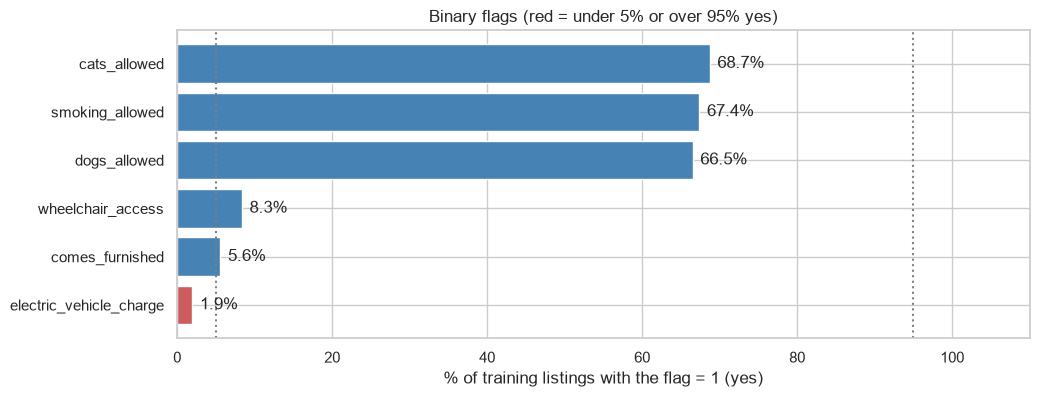

,yes_%,class
electric_vehicle_charge,1.9%,rare yes
comes_furnished,5.6%,balanced
wheelchair_access,8.3%,balanced
dogs_allowed,66.5%,balanced
smoking_allowed,67.4%,balanced
cats_allowed,68.7%,balanced


In [9]:
# 8.7 Share of "yes" for each binary flag

yes_share = (train[BINARY].mean() * 100).sort_values()
colors = ["indianred" if (v < 5 or v > 95) else "steelblue" for v in yes_share]

fig, ax = plt.subplots(figsize=(11, 4))
ax.barh(yes_share.index, yes_share.values, color=colors)
for i, v in enumerate(yes_share.values):
    ax.text(v + 1, i, f"{v:.1f}%", va="center")
ax.axvline(5, color="grey", linestyle=":")
ax.axvline(95, color="grey", linestyle=":")
ax.set_xlim(0, 110)
ax.set(xlabel="% of training listings with the flag = 1 (yes)",
       title="Binary flags (red = under 5% or over 95% yes)")
save_fig("08_binary_flags")
plt.show()

flag_class = pd.cut(yes_share, bins=[-0.1, 5, 95, 100.1], labels=["rare yes", "balanced", "dominant yes"])
display(pd.DataFrame({"yes_%": yes_share, "class": flag_class}).style.format({"yes_%": "{:.1f}%"}))

> 📌 **Findings – what our data showed** (written after reviewing the run outputs)


### 8.7 Findings

- **`electric_vehicle_charge`: 1.9% yes** → the only "rare yes" flag.
- **Balanced but low:** `comes_furnished` **5.6%**, `wheelchair_access` **8.3%**.
- **Majority yes:** `dogs_allowed` **66.5%**, `smoking_allowed` **67.4%**, `cats_allowed` **68.7%**. No flag is above 95%.
- **Two reliability notes for the report:**
  1. **Smoking allowed in two-thirds of listings** is suspiciously high for U.S. rentals; it probably reflects a Craigslist form default rather than a real policy (limitation).
  2. **Cats and dogs have almost the same share**, which suggests landlords usually allow both or neither. Step 10.1 measures how strongly they overlap.

**Decision (confirmed):** all six flags are used as 0/1 (standardised for Ridge, k-NN and MLP). Step 9.5 shows which of them relate to rent.

## 8.8 Log the Step 8 observations

As in every earlier step, `clear_obs("8")` removes older Step 8 entries, and the numbers are filled in from your results. The wording of several entries is chosen by the code from the actual values, for example whether sizes show clear heaping, or which categories fall under the rare threshold. So the log always matches your output, and nothing needs editing by hand.

**The pipeline decisions recorded here, in plain words:**

- `sqfeet`: log-transformed and standardised for Linear Regression, k-NN and the MLP; raw for the tree models.
- `beds`, `baths`: kept as numbers (ordered counts), standardised; no log.
- `lat`, `long`: blank pins filled from the region centre; standardised; most useful to the tree models.
- `region_url`: target encoding with smoothing and cross-fitting.
- `state`: one-hot encoded; redundancy with region checked in Step 10.
- `type`, `laundry_options`, `parking_options`: one-hot encoded, with categories under 1% grouped as "other".
- binary flags: used as 0/1, standardised for the sensitive models.

In [10]:
# 8.8 Log the observations

clear_obs("8")

near_const = overview.index[overview["near_constant"] == "yes"].tolist()
log_obs("8-Univariate",
        f"{len(train):,} training listings, {len(MODEL_FEATURES)} features; near-constant (>=95% one value): "
        f"{near_const if near_const else 'none'}; high-cardinality: "
        f"{overview.index[overview['high_cardinality'] == 'yes'].tolist()}",
        "8.1 feature overview",
        "High-cardinality categories need special encoding (8.5); near-constant features kept but expected to add little")

log_obs("8-Univariate",
        f"sqfeet skew {sq.skew():.2f} raw vs {log_sq.skew():.2f} after log1p (training set)",
        "8.2 summary table and histograms",
        "Log-transform and standardise sqfeet for Linear Regression, k-NN and MLP; raw values for tree models")

heaping = round_100 > 5   # far above the ~1% expected by chance
log_obs("8-Univariate",
        f"{round_100:.1f}% of sizes are multiples of 100 sq ft (about 1% expected) and {round_50:.1f}% multiples of 50"
        + (": sizes are often estimates (heaping)" if heaping else ": little sign of rounding"),
        "8.2 (cont.) rounded sizes",
        "No action; " + ("report as a data limitation that caps how precisely size can predict rent"
                         if heaping else "size precision is not a concern"))

log_obs("8-Univariate",
        f"beds skew {train['beds'].skew():.2f}, baths skew {train['baths'].skew():.2f}; "
        f"{half_bath:.1f}% have a half-bath; only {big_homes:.2f}% have 6+ bedrooms",
        "8.3 bar charts",
        "Keep beds and baths as numeric (ordered counts), standardised, no log; predictions for very large homes "
        "rest on few examples")

log_obs("8-Univariate",
        f"{no_pin.sum():,} training listings ({no_pin.mean() * 100:.2f}%) have no coordinates; lat/long are "
        f"multi-peaked (clusters of listings), coverage densest on the coasts",
        "8.4 histograms and coverage map",
        "Fill missing pins from the region centre (training data only); coordinates mainly serve tree models; "
        "linear model gets location through region encoding")

log_obs("8-Univariate",
        f"{len(per_region)} regions: median {per_region.median():.0f} listings, {int((per_region < 30).sum())} "
        f"with < 30 and {int((per_region < 100).sum())} with < 100; {len(per_state)} states; "
        f"top 15 states hold {top15.sum() / len(train) * 100:.0f}% of listings",
        "8.5 listings per category, top-15 state chart",
        "Target-encode region_url with smoothing and cross-fitting (sklearn TargetEncoder); one-hot state")

for col, r in rare.items():
    log_obs("8-Univariate",
            f"{col}: {len(r)} categories under {RARE_MIN_SHARE:.0%} "
            + (f"({', '.join(r.index)}; together {r.sum():.2f}%)" if len(r) else ""),
            "8.6 category bar charts",
            (f"One-hot encode with min_frequency = {RARE_MIN_SHARE:.0%} of training rows (rare -> 'other'); "
             "check in Step 9 whether any rare category has a very different rent") if len(r)
            else "One-hot encode; no grouping needed")

rare_flags = yes_share[yes_share < 5].index.tolist()
dominant_flags = yes_share[yes_share > 95].index.tolist()
log_obs("8-Univariate",
        f"Binary flags yes-share: " + ", ".join(f"{k} {v:.1f}%" for k, v in yes_share.items())
        + f"; rare yes: {rare_flags or 'none'}; dominant yes: {dominant_flags or 'none'}",
        "8.7 binary flag chart",
        "Use as 0/1 (standardised for sensitive models); rare flags describe small groups; "
        "smoking_allowed may reflect a Craigslist default (reliability limitation)")

show_obs(8)

,step,observation,evidence,decision
0,8-Univariate,"150,404 training listings, 16 features; near-c...",8.1 feature overview,High-cardinality categories need special encod...
1,8-Univariate,sqfeet skew 2.53 raw vs 0.14 after log1p (trai...,8.2 summary table and histograms,Log-transform and standardise sqfeet for Linea...
2,8-Univariate,21.4% of sizes are multiples of 100 sq ft (abo...,8.2 (cont.) rounded sizes,No action; report as a data limitation that ca...
3,8-Univariate,"beds skew 0.56, baths skew 0.99; 11.5% have a ...",8.3 bar charts,Keep beds and baths as numeric (ordered counts...
4,8-Univariate,969 training listings (0.64%) have no coordina...,8.4 histograms and coverage map,Fill missing pins from the region centre (trai...
5,8-Univariate,"413 regions: median 200 listings, 29 with < 30...","8.5 listings per category, top-15 state chart",Target-encode region_url with smoothing and cr...
6,8-Univariate,"type: 4 categories under 1% (cottage/cabin, fl...",8.6 category bar charts,One-hot encode with min_frequency = 1% of trai...
7,8-Univariate,laundry_options: 0 categories under 1%,8.6 category bar charts,One-hot encode; no grouping needed
8,8-Univariate,parking_options: 2 categories under 1% (no par...,8.6 category bar charts,One-hot encode with min_frequency = 1% of trai...
9,8-Univariate,Binary flags yes-share: electric_vehicle_charg...,8.7 binary flag chart,Use as 0/1 (standardised for sensitive models)...


> 📌 **Findings – what our data showed** (written after reviewing the run outputs)


## Step 8 summary – what the training data looks like

| Feature group | What we found | Decision for the pipeline |
|---|---|---|
| Size (`sqfeet`) | Median 969 sq ft; skew 2.53 → 0.14 after log; strong heaping (21.4% multiples of 100) | log + standardise (Ridge, k-NN, MLP); raw for trees; heaping = limitation |
| `beds`, `baths` | 2 beds 42.8%, 1 bath 51.2%; 11.5% half-baths; 0.12% have 6+ beds | numeric counts, standardised, no log |
| `lat`, `long` | 0.64% missing; dense coasts, sparse Mountain West; AK and HI clusters | fill from region centre (train only) |
| `region_url` | 413 regions, median 200 listings; 29 under 30 listings | smoothed, cross-fitted target encoding |
| `state` | 51 states, all ≥ 125 listings; top 15 hold 61.4% | one-hot |
| `type`, `laundry_options`, `parking_options` | 4 rare types, 2 rare (opposite) parking options; 18.1% / 31.5% missing | one-hot with a `"missing"` category; keep categories with 50+ listings (Step 9.4) |
| Binary flags | EV 1.9% yes (near-constant); smoking 67.4% suspicious | 0/1; smoking reliability = limitation |

**Corrections made to this notebook after the review:** the feature count is **16** (text in 8.1 and the 8.8 log).

> **Viva summary:** "Step 8 described each training feature on its own. It fixed the transformations (log for size, counts kept numeric), the encodings (target encoding for 413 regions, one-hot for the rest), and flagged three limitations: rounded sizes, a suspicious smoking flag, and rare categories that later turned out to differ in rent."

---

## What's next: Step 9 – Relationships with price (training set)

This step described each feature on its own. Step 9 asks the central question of the project: **how does each feature relate to rent?** Still on the training set only, it will look at:

- rent against size (on log scales), and against bedrooms and bathrooms;
- median rent by property type, laundry and parking option (including whether the rare categories found in 8.6 are too different to merge);
- rent across states and regions, and the coverage map from 8.4 coloured by rent;
- rent for listings with and without each binary flag.

These results decide which features matter most, and they're the evidence behind the choice of models.

**Writing up Step 8:** keep the interpretation of this notebook's results in the report document rather than editing the notebook. Once you've run it, send it to me and I'll draft the Step 8 findings for `reports/eda_findings.md`.